In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
print(df.shape)
print(df.info())
print(df.isnull().sum())
print(df["Churn"].value_counts())

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [4]:
print(df["Churn"].value_counts(normalize=True) * 100)
print(df.dtypes)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [5]:
##num vs cat
num_cols  = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include=["object"]).columns
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')
Categorical columns: Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='str')


C:\Users\User\AppData\Local\Temp\ipykernel_16568\1773363786.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object"]).columns


In [8]:
df["TotalCharges"].dtype

dtype('float64')

In [7]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [10]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [11]:
df.dropna(inplace=True)

In [12]:
df.shape

(7032, 21)

In [13]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


In [14]:
pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


In [15]:
pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


In [16]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [17]:
print(df["TotalCharges"].dtype)
print(df["TotalCharges"].isnull().sum())
print(pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100)
print(pd.crosstab(
    df["InternetService"],
    df["Churn"],
    normalize="index"
) * 100)
print(pd.crosstab(
    df["PaymentMethod"],
    df["Churn"],
    normalize="index"
) * 100)

print(df.groupby("Churn")["tenure"].describe())

float64
0
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665
Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211
Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
No     5163.0  37.650010  24.076940  1.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


In [18]:
df.drop(columns=["customerID"], inplace=True)
df.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [ ]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})
df.head(1)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0


In [20]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [21]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)
df_encoded.head(1)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False


In [22]:
df_encoded.shape

(7032, 31)

In [23]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,stratify=y
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(5625, 30)
(1407, 30)
(5625,)
(1407,)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score,roc_auc_score

In [26]:
log_model = LogisticRegression(max_iter=1000 , random_state=42)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

e:\Learning\DS\PJ_4_Customer_Churn_Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [28]:
y_pred[:10]
y_prob[:10]

array([0.01803384, 0.58326644, 0.00457417, 0.20396093, 0.10528705,
       0.47917863, 0.02524995, 0.16636368, 0.66764473, 0.01544408])

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)

print(cm)

print(
    classification_report(
        y_test,
        y_pred
    )
)

Accuracy: 0.8031272210376688
[[915 118]
 [159 215]]
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [30]:
roc_auc = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", roc_auc)

ROC AUC: 0.836503667734805


In [33]:
#coefficients = pd.DataFrame({"Feature": X.columns, "Coefficient": log_model.coef_[0]})
coefficients.sort_values(by="Coefficient", ascending=False).head(10)

,Feature,Coefficient
10,InternetService_Fiber optic,0.683630
28,PaymentMethod_Electronic check,0.390160
26,PaperlessBilling_Yes,0.298448
9,MultipleLines_Yes,0.278615
8,MultipleLines_No phone service,0.252229
21,StreamingTV_Yes,0.205085
0,SeniorCitizen,0.196803
23,StreamingMovies_Yes,0.176875
29,PaymentMethod_Mailed check,0.077059
27,PaymentMethod_Credit card (automatic),0.038419


In [32]:
X.head(2)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True


In [34]:
coefficients.sort_values(
    by="Coefficient"
).head(10)

,Feature,Coefficient
25,Contract_Two year,-1.366697
24,Contract_One year,-0.748660
13,OnlineSecurity_Yes,-0.459962
7,PhoneService_Yes,-0.436050
19,TechSupport_Yes,-0.420657
6,Dependents_Yes,-0.229427
15,OnlineBackup_Yes,-0.213131
12,OnlineSecurity_No internet service,-0.106049
16,DeviceProtection_No internet service,-0.106049
18,TechSupport_No internet service,-0.106049


In [35]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
rf_auc = roc_auc_score(y_test, rf_prob)
print("Random Forest ROC AUC:", rf_auc)

Random Forest Accuracy: 0.7867803837953091
[[917 116]
 [184 190]]
              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1033
           1       0.62      0.51      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

Random Forest ROC AUC: 0.8180808713523251


In [36]:
feature_importances = pd.DataFrame(
    {"Feature": X.columns, "Importance": rf_model.feature_importances_}
)
feature_importances.sort_values(by="Importance", ascending=False).head(10)

,Feature,Importance
3,TotalCharges,0.194313
1,tenure,0.168529
2,MonthlyCharges,0.167972
10,InternetService_Fiber optic,0.038913
28,PaymentMethod_Electronic check,0.037898
25,Contract_Two year,0.031862
4,gender_Male,0.028939
13,OnlineSecurity_Yes,0.027288
26,PaperlessBilling_Yes,0.025595
5,Partner_Yes,0.023280


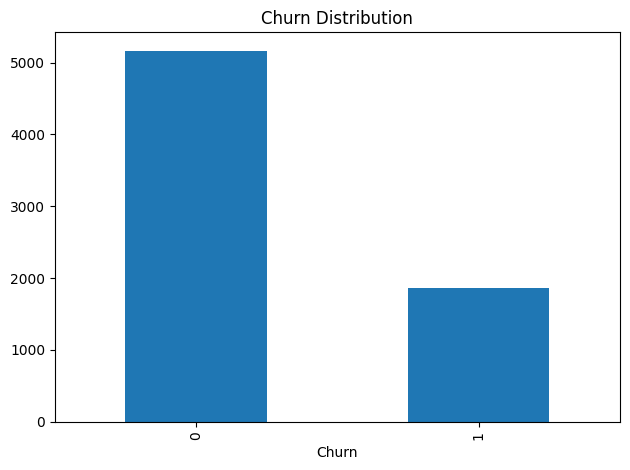

In [40]:
import matplotlib.pyplot as plt
df["Churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.tight_layout()
plt.savefig("../assets/churn_distribution.png")


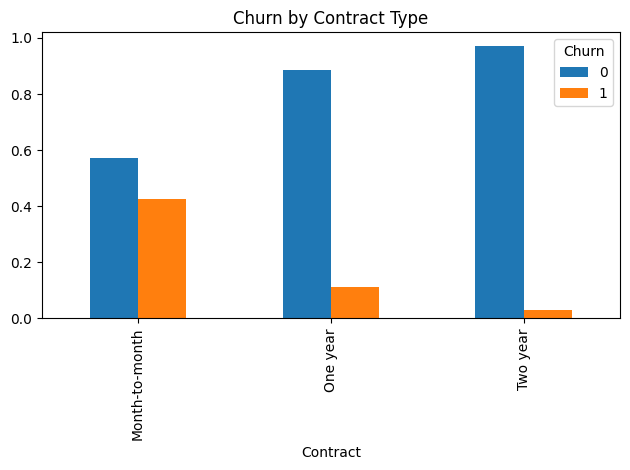

In [41]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
).plot(kind="bar")
plt.title("Churn by Contract Type")
plt.tight_layout()
plt.savefig("../assets/churn_by_contract.png")

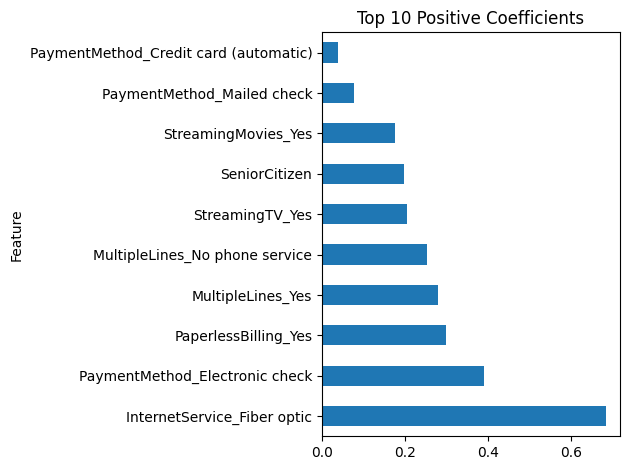

In [42]:
top_positive = coefficients.sort_values(
    by="Coefficient",
    ascending=False
).head(10).plot(kind="barh", x="Feature", y="Coefficient", legend=False)
plt.title("Top 10 Positive Coefficients")
plt.tight_layout()
plt.savefig("../assets/top_positive_coefficients.png")


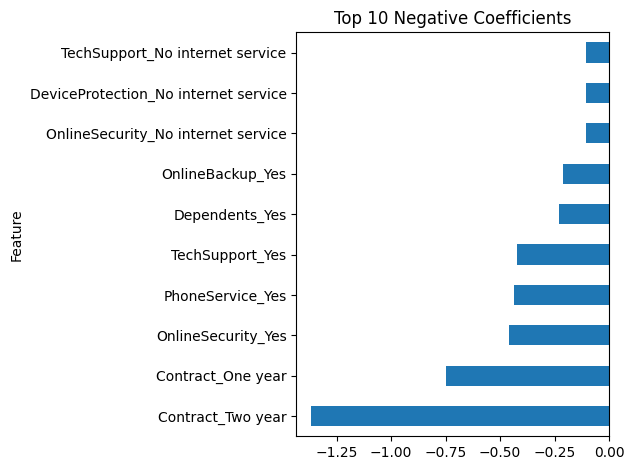

In [43]:
top_negative = coefficients.sort_values(
    by="Coefficient"
).head(10).plot(kind="barh", x="Feature", y="Coefficient", legend=False)
plt.title("Top 10 Negative Coefficients")
plt.tight_layout()
plt.savefig("../assets/top_negative_coefficients.png")
